# 🚁 Pi0 Drone VLA — Inference Test (Kaggle)
### Menggunakan Checkpoint 2500 Steps

Notebook ini melakukan **pengujian inferensi** terhadap model Pi0 Drone VLA yang telah dilatih.
Pastikan dataset `dronepivla` sudah di-attach dan GPU T4 sudah aktif.

In [1]:
import os, subprocess, shutil, sys

# Nama dataset kamu di Kaggle (URL Slug) - SAMA PERSIS dengan notebook training
DATASET_NAME = 'dronepivla'
# Path ini harus sama dengan yang berhasil di notebook training
KAGGLE_BASE = f'/kaggle/input//datasets/sjankaczar/{DATASET_NAME}'

# Path ke source OpenPI (sama persis dengan training)
OPENPI_DIR     = f'{KAGGLE_BASE}/openpi/openpi'
DATASET_DIR    = f'{KAGGLE_BASE}/drone_roblox/drone_roblox'
NORMSTATS_DIR  = f'{KAGGLE_BASE}/norm_stats'
# Path ke checkpoint 2500 steps yang ada di dalam dataset kamu
CHECKPOINT_INPUT_DIR = f'{KAGGLE_BASE}/training 2500 steps'

OPENPI_ZIP   = f'{KAGGLE_BASE}/openpi.zip'
DATASET_ZIP  = f'{KAGGLE_BASE}/drone_roblox.zip'

print('✅ Lingkungan Kaggle Terdeteksi. Memeriksa file...')

def check_path(dir_path, zip_path=None):
    if os.path.isdir(dir_path): return dir_path
    if zip_path and os.path.exists(zip_path): return zip_path
    return None

FINAL_OPENPI       = check_path(OPENPI_DIR, OPENPI_ZIP)
FINAL_DATASET      = check_path(DATASET_DIR, DATASET_ZIP)
FINAL_CHECKPOINT   = check_path(CHECKPOINT_INPUT_DIR)
FINAL_NORMSTATS    = check_path(NORMSTATS_DIR)

missing = False
for name, p in [
    ('OpenPI Source', FINAL_OPENPI),
    ('Drone Dataset', FINAL_DATASET),
    ('Checkpoint 2500 Steps', FINAL_CHECKPOINT),
    ('model.safetensors', os.path.join(CHECKPOINT_INPUT_DIR, 'model.safetensors') if FINAL_CHECKPOINT else None),
]:
    if p and os.path.exists(p):
        print(f'  ✅ {name} Ditemukan di: {p}')
    else:
        print(f'  ❌ {name} TIDAK DITEMUKAN!')
        missing = True

if missing:
    print('\n⚠️ PERINGATAN: File tidak ditemukan di path default.')
    print('Mencoba melacak struktur folder di /kaggle/input/ ...')
    for root, dirs, files in os.walk('/kaggle/input/'):
        level = root.replace('/kaggle/input/', '').count(os.sep)
        if level < 5:  # Batasi kedalaman untuk keterbacaan
            indent = ' ' * 4 * level
            print(f'{indent}{os.path.basename(root)}/')
else:
    print('\n🚀 Semua file siap untuk proses inferensi!')

✅ Lingkungan Kaggle Terdeteksi. Memeriksa file...
  ✅ OpenPI Source Ditemukan di: /kaggle/input//datasets/sjankaczar/dronepivla/openpi/openpi
  ✅ Drone Dataset Ditemukan di: /kaggle/input//datasets/sjankaczar/dronepivla/drone_roblox/drone_roblox
  ✅ Checkpoint 2500 Steps Ditemukan di: /kaggle/input//datasets/sjankaczar/dronepivla/training 2500 steps
  ✅ model.safetensors Ditemukan di: /kaggle/input//datasets/sjankaczar/dronepivla/training 2500 steps/model.safetensors

🚀 Semua file siap untuk proses inferensi!


In [2]:
%%time
# ^-- Tetap di baris pertama tanpa ada komentar di atasnya!

import subprocess, sys

def pip_install(*args):
    """Run pip install with given arguments."""
    cmd = [sys.executable, '-m', 'pip', 'install', '--quiet', '--no-warn-conflicts', *args]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f'⚠️  Warning during install: {result.stderr[-500:]}')
    return result.returncode

# Step 0: Pembersihan Total (Kaggle sering punya library sisa yang bentrok)
print('🧹 Step 0: Nuking existing JAX, Numpy, and Torch to prevent version mismatch...')
subprocess.run([sys.executable, '-m', 'pip', 'uninstall', 'jax', 'jaxlib', 'numpy', 'torch', 'torchaudio', 'torchvision', '-y'], capture_output=True)

print('📦 Step 1: Installing Numpy 1.26.4 (CRITICAL: Fixes the umath error)...')
pip_install('numpy==1.26.4')

print('📦 Step 2: Installing Torch & Core ML libraries...')
pip_install(
    'torch==2.4.0', 'torchvision', 'torchaudio', '--index-url', 'https://download.pytorch.org/whl/cu121',
    'safetensors>=0.4.0',
    'einops>=0.8.0',
    'wandb>=0.19.1',
)

print('📦 Step 3: Installing JAX + Flax ecosystem (0.5.3)...')
pip_install(
    'jax[cuda12]==0.5.3',
    'jaxlib==0.5.3',
    'flax==0.10.2',
    'orbax-checkpoint==0.11.13',
    'chex',
    'equinox>=0.11.8',
    'ml-collections==1.0.0',
    'jaxtyping==0.2.36',
    'ml-dtypes==0.4.1',
)

print('📦 Step 4: Installing data libraries...')
pip_install(
    'lerobot@git+https://github.com/huggingface/lerobot@0cf864870cf29f4738d3ade893e6fd13fbd7cdb5',
    'datasets',
    'huggingface-hub',
)

print('📦 Step 5: Installing all utility libraries (FULL LIST)...')
pip_install(
    'tyro>=0.9.5',
    'beartype==0.19.0',
    'numpydantic>=1.6.6',
    'sentencepiece>=0.2.0',
    'tqdm-loggable>=0.2',
    'humanize',
    'filelock>=3.16.1',
    'treescope>=0.1.7',
    'augmax>=0.3.4',
    'dm-tree>=0.1.8',
    'flatbuffers>=24.3.25',
    'fsspec==2023.10.0',
    'gcsfs',
    'imageio>=2.36.1',
    'opencv-python-headless',
    'pillow>=11.0.0',
    'rich>=14.0.0',
    'polars>=1.30.0',
    'transformers==4.53.2',
    'gym-aloha>=0.1.1',
)

print('\n✅ All dependencies installed!')
print('⚠️  WAJIB: Klik menu "Run" (panel atas Kaggle) -> "Restart Kernel"!')

🧹 Step 0: Nuking existing JAX, Numpy, and Torch to prevent version mismatch...
📦 Step 1: Installing Numpy 1.26.4 (CRITICAL: Fixes the umath error)...
📦 Step 2: Installing Torch & Core ML libraries...
📦 Step 3: Installing JAX + Flax ecosystem (0.5.3)...
📦 Step 4: Installing data libraries...
📦 Step 5: Installing all utility libraries (FULL LIST)...

✅ All dependencies installed!
⚠️  WAJIB: Klik menu "Run" (panel atas Kaggle) -> "Restart Kernel"!
CPU times: user 14.5 ms, sys: 5.74 ms, total: 20.2 ms
Wall time: 6min 19s


In [3]:
import os, shutil, glob, subprocess, sys, zipfile

HOME_DIR = os.path.expanduser('~')
TARGET_DATA_DIR = os.path.join(HOME_DIR, '.cache/huggingface/lerobot/rafli/drone_roblox')
WORK_DIR = '/kaggle/working/openpi'

def smart_copy_or_extract(source, target_parent, target_name):
    """Menangani folder atau zip dari input ke working directory."""
    target_path = os.path.join(target_parent, target_name)
    if os.path.exists(target_path): shutil.rmtree(target_path)
    if os.path.isdir(source):
        print(f'📁 Menyalin folder {os.path.basename(source)}...')
        shutil.copytree(source, target_path)
    elif zipfile.is_zipfile(source):
        print(f'📦 Mengekstrak zip {os.path.basename(source)}...')
        with zipfile.ZipFile(source, 'r') as z:
            z.extractall(target_parent)
    else:
        print(f'❌ ERROR: Sumber tidak valid: {source}')

# 1. Siapkan OpenPI
print('🚀 1/3: Menyiapkan OpenPI...')
smart_copy_or_extract(FINAL_OPENPI, '/kaggle/working', 'openpi')

print('📦 Menyambungkan kode OpenPI ke sistem Python...')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-e', WORK_DIR, '--no-deps'])

# 2. Siapkan Dataset LeRobot (di folder Cache agar bisa dibaca policy)
print('\n🚀 2/3: Menyiapkan Dataset LeRobot...')
temp_data_path = '/kaggle/working/temp_dataset'
smart_copy_or_extract(FINAL_DATASET, '/kaggle/working', 'temp_dataset')
matches = glob.glob(os.path.join(temp_data_path, '**/meta/info.json'), recursive=True)
if matches:
    actual_root = os.path.dirname(os.path.dirname(matches[0]))
    os.makedirs(os.path.dirname(TARGET_DATA_DIR), exist_ok=True)
    if os.path.exists(TARGET_DATA_DIR): shutil.rmtree(TARGET_DATA_DIR)
    shutil.move(actual_root, TARGET_DATA_DIR)
    print(f'✅ Dataset siap di: {TARGET_DATA_DIR}')
else:
    print('❌ ERROR: info.json tidak ditemukan!')

# 3. Siapkan Assets (Norm Stats) dari norm_stats folder atau checkpoint
print('\n🚀 3/3: Menyiapkan Norm Stats...')
FINAL_TARGET_NS = '/kaggle/working/assets/pi0_drone_lite/rafli/drone_roblox'

# Coba dari folder norm_stats dedicated dulu
ns_source = None
temp_ns_path = '/kaggle/working/temp_ns' # Definisikan di luar agar aman saat cleanup
if FINAL_NORMSTATS and os.path.exists(FINAL_NORMSTATS):
    smart_copy_or_extract(FINAL_NORMSTATS, '/kaggle/working', 'temp_ns')
    ns_matches = glob.glob(os.path.join(temp_ns_path, '**/norm_stats.json'), recursive=True)
    if ns_matches:
        ns_source = os.path.dirname(ns_matches[0])

# Fallback: ambil dari dalam checkpoint 2500 steps
if not ns_source:
    ckpt_ns_path = os.path.join(CHECKPOINT_INPUT_DIR, 'assets', 'rafli', 'drone_roblox')
    if os.path.exists(ckpt_ns_path):
        ns_source = ckpt_ns_path
        print(f'  (Menggunakan norm_stats dari dalam checkpoint)')

if ns_source:
    if os.path.exists(FINAL_TARGET_NS): shutil.rmtree(FINAL_TARGET_NS)
    os.makedirs(os.path.dirname(FINAL_TARGET_NS), exist_ok=True)
    
    # SALIN DULU DATA KE TARGET SEBELUM TEMP_NS DIHAPUS
    shutil.copytree(ns_source, FINAL_TARGET_NS)
    print(f'🚀 Norm Stats siap di: {FINAL_TARGET_NS}')
    print(f'📊 File di dalam: {os.listdir(FINAL_TARGET_NS)}')
else:
    print('❌ ERROR: norm_stats.json tidak ditemukan!')

# BERSIHKAN SAMPAH TEMP DI AKHIR (Setelah semua copy selesai)
for t in [temp_data_path, temp_ns_path]:
    if os.path.exists(t):
        shutil.rmtree(t)
        print(f"🧹 Menghapus folder temp: {t}")

print('\n✨ PERSIAPAN FILE SELESAI!')

🚀 1/3: Menyiapkan OpenPI...
📁 Menyalin folder openpi...
📦 Menyambungkan kode OpenPI ke sistem Python...
Obtaining file:///kaggle/working/openpi
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for openpi (pyproject.toml): started
  Building editable for openpi (pyproject.toml): finished with status 'done'
  Created wheel for openpi: filename=openpi-0.1.0-py3-none-any.whl size=20285 sha256=a5138a0a9f7f9350525c06b4583c4ee56fa

In [4]:
!pip install peft --quiet

In [5]:
import os, torch, sys, shutil

import transformers, lerobot
HOME_DIR = os.path.expanduser('~')
TARGET_DATA_DIR = os.path.join(HOME_DIR, '.cache/huggingface/lerobot/rafli/drone_roblox/drone_roblox')

def patch_recursive(src, dst):
    """Menyisipkan file satu per satu tanpa menghapus folder asli sistem."""
    for item in os.listdir(src):
        s = os.path.join(src, item)
        d = os.path.join(dst, item)
        if os.path.isdir(s):
            if not os.path.exists(d): os.makedirs(d)
            patch_recursive(s, d)
        else:
            shutil.copy2(s, d)

print('🛠️ Memulai proses patching file (LATEST-FORCE-RESTORE Mode)...')

# 1. Patch OpenPI (Fix datetime.UTC)
download_py = '/kaggle/working/openpi/src/openpi/shared/download.py'
if os.path.exists(download_py):
    with open(download_py, 'r') as f:
        content = f.read().replace('datetime.UTC', 'datetime.timezone.utc')
    with open(download_py, 'w') as f:
        f.write(content)
    print('✅ Patch 1/4: OpenPI download.py OK.')

# 2. Patch LeRobot (Fix TypeError: stack())
lerobot_lib_path = os.path.dirname(lerobot.__file__)
lerobot_ds_py = os.path.join(lerobot_lib_path, 'common/datasets/lerobot_dataset.py')
if os.path.exists(lerobot_ds_py):
    with open(lerobot_ds_py, 'r') as f:
        content = f.read()
    replacements = [
        ('torch.stack(self.hf_dataset["timestamp"])', 'torch.stack(list(self.hf_dataset["timestamp"]))'),
        ('torch.stack(self.hf_dataset["episode_index"])', 'torch.stack(list(self.hf_dataset["episode_index"]))'),
        ('torch.stack(self.hf_dataset["index"])', 'torch.stack(list(self.hf_dataset["index"]))'),
        ('torch.stack(self.hf_dataset["task_index"])', 'torch.stack(list(self.hf_dataset["task_index"]))'),
        ('torch.stack(self.hf_dataset.select(q_idx)[key])', 'torch.stack(list(self.hf_dataset.select(q_idx)[key]))')
    ]
    for old, new in replacements:
        content = content.replace(old, new)
    with open(lerobot_ds_py, 'w') as f:
        f.write(content)
    print('✅ Patch 2/4: LeRobot dataset.py OK.')

# 3. Patch Transformers (OpenPI Custom Model Patch)
transformers_path = os.path.dirname(transformers.__file__)
patch_source = '/kaggle/working/openpi/src/openpi/models_pytorch/transformers_replace'
if os.path.exists(patch_source):
    patch_recursive(patch_source, transformers_path)
    print('✅ Patch 3/4: Transformers OpenPI-Files OK.')

# 4. Patch Model Loading (KHUSUS UNTUK LORA INFERENCE & NON-STRICT LOAD)
model_py = '/kaggle/working/openpi/src/openpi/models/model.py'
if os.path.exists(model_py):
    with open(model_py, 'r') as f:
        content = f.read()
    
    # KODE BARU: Mengikuti logika FORCE RESUME Anda (tanpa memanggil load_model asli)
    lora_patch = """
        # --- PATCH LORA INFERENCE (MATCH FORCE RESUME) ---
        from safetensors.torch import load_file
        print(f"🚀 Memuat checkpoint taktis dari: {weight_path}")
        try:
            from peft import get_peft_model, LoraConfig
            print("   ↳ Menyuntikkan struktur LoRA (r=8)...")
            lora_config = LoraConfig(
                r=8, lora_alpha=16, target_modules="all-linear", bias="none"
            )
            model = get_peft_model(model, lora_config)
            
            print("   ↳ Memasukkan bobot ke model (strict=False)...")
            state_dict = load_file(weight_path)
            model.load_state_dict(state_dict, strict=False)
            print(f"✅ Bobot LoRA Berhasil Dimuat! (Keys matched: {len(state_dict)})")
        except Exception as e:
            print(f"❌ ERROR SAAT MUAT LORA: {e}")
        # -------------------------------------------------
    """
    
    if "PATCH LORA INFERENCE" not in content:
        # Kita replace seluruh baris safetensors.torch.load_model dengan patch kita
        # Pastikan tidak ada safetensors.torch.load_model yang terpanggil lagi
        content = content.replace("safetensors.torch.load_model(model, weight_path)", lora_patch)
        with open(model_py, 'w') as f:
            f.write(content)
        print('✅ Patch 4/4: Model.py LATEST-RESTORE OK.')

print('-' * 50)
print('🚀 Patch Selesai! Silakan jalankan ulang sel pengujian model.')


🛠️ Memulai proses patching file (LATEST-FORCE-RESTORE Mode)...
✅ Patch 1/4: OpenPI download.py OK.
✅ Patch 2/4: LeRobot dataset.py OK.
✅ Patch 3/4: Transformers OpenPI-Files OK.
✅ Patch 4/4: Model.py LATEST-RESTORE OK.
--------------------------------------------------
🚀 Patch Selesai! Silakan jalankan ulang sel pengujian model.


In [6]:
# ============================================================
# Patch LeRobot Tambahan (Fix TypeError: stack() - double check)
# ============================================================
import os, lerobot

lerobot_lib_path = os.path.dirname(lerobot.__file__)
lerobot_file = os.path.join(lerobot_lib_path, 'common/datasets/lerobot_dataset.py')

print(f'🔍 Mencari file di: {lerobot_file}')

if os.path.exists(lerobot_file):
    with open(lerobot_file, 'r') as f:
        content = f.read()

    replacements = [
        ('torch.stack(self.hf_dataset["timestamp"])', 'torch.stack(list(self.hf_dataset["timestamp"]))'),
        ('torch.stack(self.hf_dataset["episode_index"])', 'torch.stack(list(self.hf_dataset["episode_index"]))'),
        ('torch.stack(self.hf_dataset["index"])', 'torch.stack(list(self.hf_dataset["index"]))'),
        ('torch.stack(self.hf_dataset["task_index"])', 'torch.stack(list(self.hf_dataset["task_index"]))'),
        ('torch.stack(self.hf_dataset.select(q_idx)[key])', 'torch.stack(list(self.hf_dataset.select(q_idx)[key]))')
    ]

    patched_count = 0
    for old, new in replacements:
        if old in content:
            content = content.replace(old, new)
            patched_count += 1
            print(f'✅ Patching: {old[:50]}...')

    if patched_count > 0:
        with open(lerobot_file, 'w') as f:
            f.write(content)
        print(f'\n🎉 Berhasil menerapkan {patched_count} patch!')
    else:
        print('\nℹ️  Semua patch sudah diterapkan sebelumnya.')
else:
    print(f'❌ ERROR: File LeRobot tidak ditemukan!')

🔍 Mencari file di: /usr/local/lib/python3.12/dist-packages/lerobot/common/datasets/lerobot_dataset.py

ℹ️  Semua patch sudah diterapkan sebelumnya.


In [7]:
# ============================================================
# Pre-download PaliGemma Tokenizer (WAJIB agar model bisa dimuat)
# ============================================================
import os
import urllib.request

print('🛠️ Mempersiapkan PaliGemma Tokenizer secara manual...')

cache_dir = '/root/.cache/openpi/big_vision'
os.makedirs(cache_dir, exist_ok=True)

tokenizer_url  = 'https://storage.googleapis.com/big_vision/paligemma_tokenizer.model'
target_path    = os.path.join(cache_dir, 'paligemma_tokenizer.model')

if not os.path.exists(target_path):
    print(f'⬇️ Sedang mengunduh Tokenizer ke {target_path} (sekitar 4 MB)...')
    try:
        urllib.request.urlretrieve(tokenizer_url, target_path)
        print('✅ Unduhan Tokenizer BERHASIL!')
    except Exception as e:
        print(f'❌ ERROR saat mengunduh: {e}')
else:
    print('✅ Tokenizer sudah tersedia di direktori target.')

🛠️ Mempersiapkan PaliGemma Tokenizer secara manual...
⬇️ Sedang mengunduh Tokenizer ke /root/.cache/openpi/big_vision/paligemma_tokenizer.model (sekitar 4 MB)...
✅ Unduhan Tokenizer BERHASIL!


In [8]:
# ============================================================
# Setup sys.path dan konfigurasi environment untuk inferensi
# ============================================================
import sys, os, torch

# Path harus sama persis dengan yang dipakai script training
OPENPI_SRC_PATH     = '/kaggle/working/openpi/src'
OPENPI_CLIENT_PATH  = '/kaggle/working/openpi/packages/openpi-client/src'

for p in [OPENPI_SRC_PATH, OPENPI_CLIENT_PATH]:
    if p not in sys.path:
        sys.path.insert(0, p)

os.environ['PYTHONPATH']                 = f'{OPENPI_SRC_PATH}:{OPENPI_CLIENT_PATH}'
os.environ['HF_HUB_OFFLINE']            = '1'
os.environ['JAX_PLATFORMS']             = 'cpu'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['PYTORCH_CUDA_ALLOC_CONF']   = 'expandable_segments:True'

# Path checkpoint yang ada di dalam input dataset kamu
CHECKPOINT_DIR = CHECKPOINT_INPUT_DIR  # = KAGGLE_BASE + '/training 2500 steps'

print('--- ⚙️ Konfigurasi Inferensi ---')
print(f'Checkpoint Dir:  {CHECKPOINT_DIR}')
print(f'model.safetensors exists: {os.path.exists(os.path.join(CHECKPOINT_DIR, "model.safetensors"))}')
print(f'assets exists:            {os.path.exists(os.path.join(CHECKPOINT_DIR, "assets"))}')
print(f'CUDA Available:           {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:                      {torch.cuda.get_device_name(0)}')
    print(f'VRAM:                     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

--- ⚙️ Konfigurasi Inferensi ---
Checkpoint Dir:  /kaggle/input//datasets/sjankaczar/dronepivla/training 2500 steps
model.safetensors exists: True
assets exists:            True
CUDA Available:           True
GPU:                      Tesla T4
VRAM:                     15.6 GB


In [9]:
# ============================================================
# MUAT MODEL PI0 DARI CHECKPOINT 2500 STEPS
# ============================================================
import torch

from openpi.training import config as _config
from openpi.policies import policy_config as _policy_config

torch.cuda.empty_cache()

# Muat konfigurasi training yang sama persis dengan waktu training
train_config = _config.get_config('pi0_drone_lite')

print(f'✅ Config "{train_config.name}" dimuat.')
print(f'   action_dim:     {train_config.model.action_dim}  (internal)')
print(f'   action_horizon: {train_config.model.action_horizon}')
print(f'   paligemma:      {train_config.model.paligemma_variant}')
print()

# create_trained_policy secara otomatis:
# 1. Mendeteksi model.safetensors -> muat sebagai PyTorch model
# 2. Muat norm_stats dari CHECKPOINT_DIR/assets/rafli/drone_roblox/
# 3. Membangun pipeline transforms (DroneInputs, Normalize, dll)
# 4. Return Policy object yang siap untuk .infer()

print(f'🚀 Memuat model dari: {CHECKPOINT_DIR}')
print('   (Proses ini bisa memakan waktu 2-5 menit pertama kali)\n')

policy = _policy_config.create_trained_policy(
    train_config,
    CHECKPOINT_DIR,
    pytorch_device='cuda' if torch.cuda.is_available() else 'cpu',
)

if torch.cuda.is_available():
    vram_used  = torch.cuda.memory_allocated() / 1e9
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'\n📊 Penggunaan VRAM setelah load: {vram_used:.2f} GB / {vram_total:.1f} GB')

print('\n✅ Policy berhasil dimuat dan siap untuk inferensi!')

2026-04-10 15:36:46.798773: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775835407.045038      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775835407.111828      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775835407.658790      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775835407.658829      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775835407.658832      55 computation_placer.cc:177] computation placer alr

✅ Config "pi0_drone_lite" dimuat.
   action_dim:     32  (internal)
   action_horizon: 10
   paligemma:      gemma_2b_lora

🚀 Memuat model dari: /kaggle/input//datasets/sjankaczar/dronepivla/training 2500 steps
   (Proses ini bisa memakan waktu 2-5 menit pertama kali)

🚀 Memuat checkpoint taktis dari: /kaggle/input/datasets/sjankaczar/dronepivla/training 2500 steps/model.safetensors
   ↳ Menyuntikkan struktur LoRA (r=8)...
   ↳ Memasukkan bobot ke model (strict=False)...
✅ Bobot LoRA Berhasil Dimuat! (Keys matched: 1621)

📊 Penggunaan VRAM setelah load: 7.06 GB / 15.6 GB

✅ Policy berhasil dimuat dan siap untuk inferensi!


In [18]:
TARGET_DATA_DIR = '/kaggle/input/datasets/sjankaczar/dronepivla/drone_roblox/drone_roblox'

🔍 Memproses data dari: /kaggle/input/datasets/sjankaczar/dronepivla/drone_roblox/drone_roblox/data/chunk-000/episode_000000.parquet
💡 Gambar ditemukan dalam format Dictionary, mengekstrak bytes...
✅ Instruksi (Index 0): "look at the red cube"
✅ BERHASIL! Gambar asli (224, 224, 3) dimuat.


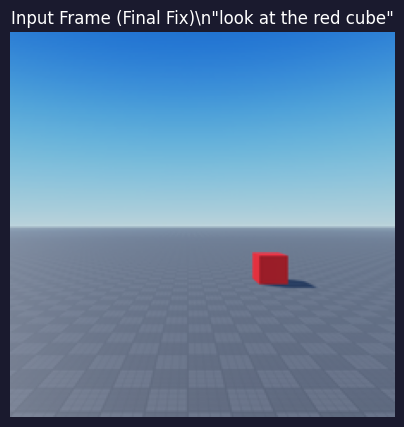

In [19]:
# ============================================================
# SIAPKAN OBSERVASI (FIX: DICT IMAGE & TASK LOOKUP)
# ============================================================
import os, io, json
import polars as pl
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

parquet_file = os.path.join(TARGET_DATA_DIR, 'data/chunk-000/episode_000000.parquet')
tasks_file = os.path.join(TARGET_DATA_DIR, 'meta/tasks.jsonl')

print(f"🔍 Memproses data dari: {parquet_file}")

try:
    if not os.path.exists(parquet_file):
        raise FileNotFoundError("File Parquet tidak ditemukan!")

    # 1. Baca Parquet
    df = pl.read_parquet(parquet_file)
    first_row = df.row(0, named=True)
    
    # 2. Ekstrak Gambar dari Dictionary
    image_col = first_row.get('image')
    image_bytes = None
    
    if isinstance(image_col, dict):
        # LeRobot biasanya menyimpan data biner di key 'bytes' atau 'data'
        image_bytes = image_col.get('bytes') or image_col.get('data') or image_col.get('path')
        print("💡 Gambar ditemukan dalam format Dictionary, mengekstrak bytes...")
    else:
        image_bytes = image_col

    if image_bytes is None:
        raise KeyError(f"Tidak bisa menemukan data biner di kolom image! Keys: {list(image_col.keys()) if isinstance(image_col, dict) else 'Bukan Dict'}")

    # Konversi ke Numpy
    img_pil = Image.open(io.BytesIO(image_bytes)).convert('RGB').resize((224, 224))
    sample_image = np.array(img_pil)
    
    # 3. Lookup Instruksi via task_index
    instruction = "look at the red cube" # Default
    task_idx = first_row.get('task_index')
    
    if task_idx is not None and os.path.exists(tasks_file):
        with open(tasks_file, 'r') as f:
            tasks = [json.loads(line) for line in f]
            if task_idx < len(tasks):
                instruction = tasks[task_idx].get('task', instruction)
        print(f"✅ Instruksi (Index {task_idx}): \"{instruction}\"")

    print(f"✅ BERHASIL! Gambar asli {sample_image.shape} dimuat.")

except Exception as e:
    print(f"❌ ERROR: {e}")
    print("⚠️ Menggunakan gambar dummy sebagai fallback...")
    sample_image = np.zeros((224, 224, 3), dtype=np.uint8)
    sample_image[70:154, 70:154] = [220, 50, 50]
    instruction = "look at the red cube (fallback)"

# Visualisasi
plt.figure(figsize=(5, 5), facecolor='#1a1a2e')
plt.imshow(sample_image)
plt.title(f'Input Frame (Final Fix)\\n"{instruction}"', color='white')
plt.axis('off')
plt.show()

# Berikan ke variabel observation untuk inferensi
observation = {
    'image': sample_image.astype(np.uint8),
    'state': np.zeros(4, dtype=np.float32),
    'task': instruction,
}


In [20]:
# ============================================================
# JALANKAN INFERENSI
# ============================================================

# Siapkan observation dalam format yang diharapkan DroneInputs transform:
#   - 'image'  : np.ndarray (H, W, 3) uint8 -> DroneInputs akan mengonversi ke range [-1, 1]
#   - 'state'  : np.ndarray float32 (4,)    -> kecepatan saat ini [vx, vy, vz, yaw]
#   - 'task'   : str                         -> instruksi bahasa manusia

observation = {
    'image': sample_image,                      # (224, 224, 3) uint8
    'state': np.zeros(4, dtype=np.float32),     # Drone idle, kecepatan = 0
    'task':  instruction,
}

print('📤 Mengirim observasi ke model...')
print(f'  Image shape:  {observation["image"].shape}')
print(f'  State values: {observation["state"]}')
print(f'  Task:         {observation["task"]}')
print()

# Jalankan inferensi
with torch.no_grad():
    result = policy.infer(observation)

print('✅ Inferensi berhasil!')

📤 Mengirim observasi ke model...
  Image shape:  (224, 224, 3)
  State values: [0. 0. 0. 0.]
  Task:         look at the red cube



/usr/local/lib/python3.12/dist-packages/torch/_dynamo/variables/functions.py:2082: UserWarning: Dynamo does not know how to trace the builtin `builtins.__build_class__.` This function is either a Python builtin (e.g. _warnings.warn) or a third-party C/C++ Python extension (perhaps created with pybind).
If it is a Python builtin, please file an issue on GitHub so the PyTorch team can add support for it and see the next case for a workaround.
If it is a third-party C/C++ Python extension, please either wrap it into a PyTorch-understood custom operator (see https://pytorch.org/tutorials/advanced/custom_ops_landing_page.html for more details) or, if it is traceable, use `torch.compiler.allow_in_graph`.
  torch._dynamo.utils.warn_once(explanation + "\n" + "\n".join(hints))
W0410 15:51:48.564000 55 torch/_inductor/utils.py:1731] [6/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2941: UserWarning: Tesla T4 does not support

✅ Inferensi berhasil!


In [21]:
# ============================================================
# ANALISIS HASIL PREDIKSI
# ============================================================
import numpy as np

actions = result['actions']  # Shape: (action_horizon, 4)

print('=' * 65)
print('  HASIL INFERENSI MODEL PI0 DRONE VLA (2500 STEPS)')
print('=' * 65)
print(f'  Actions shape:       {actions.shape}')

if actions.shape[-1] == 4:
    status = '✅ BENAR — 4D (Vx, Vy, Vz, Yaw)'
else:
    status = f'⚠️  Tidak terduga: {actions.shape[-1]}D'
    
print(f'  Dimensi per timestep: {actions.shape[-1]}  ← {status}')
print(f'  Horizon prediksi:    {actions.shape[0]} timestep')
print()
print(f'  {"Step":<6} {"Vx (Maju)":>14} {"Vy (Samping)":>14} {"Vz (Naik)": >14} {"Yaw (Rotasi)":>14}')
print(f'  {"-"*62}')

for i in range(actions.shape[0]):
    vx, vy, vz, yaw = actions[i]
    print(f'  {i:<6} {vx:>14.6f} {vy:>14.6f} {vz:>14.6f} {yaw:>14.6f}')

print(f'  {"-"*62}')
print()
print('📊 Statistik Rata-rata Prediksi:')
print(f'  Mean Vx   (Maju):        {actions[:, 0].mean():>10.6f}')
print(f'  Mean Vy   (Samping):     {actions[:, 1].mean():>10.6f}')
print(f'  Mean Vz   (Naik/Turun):  {actions[:, 2].mean():>10.6f}')
print(f'  Mean Yaw  (Rotasi):      {actions[:, 3].mean():>10.6f}')
print()
print('=' * 65)
if actions.shape[-1] == 4:
    print('✅ KESIMPULAN: Model berhasil menghasilkan 4-dimensional actions!')
    print('   Output order: [Vx, Vy, Vz, Yaw] sesuai dengan DroneOutputs')
else:
    print(f'⚠️  PERINGATAN: Output memiliki {actions.shape[-1]} dimensi (bukan 4).')
print('=' * 65)

  HASIL INFERENSI MODEL PI0 DRONE VLA (2500 STEPS)
  Actions shape:       (10, 4)
  Dimensi per timestep: 4  ← ✅ BENAR — 4D (Vx, Vy, Vz, Yaw)
  Horizon prediksi:    10 timestep

  Step        Vx (Maju)   Vy (Samping)      Vz (Naik)   Yaw (Rotasi)
  --------------------------------------------------------------
  0            0.000002       0.000001      -0.000001       0.004042
  1            0.000002       0.000001       0.000001      -0.004891
  2           -0.000001       0.000001       0.000001       0.034034
  3            0.000002      -0.000000      -0.000000       0.072808
  4           -0.000000       0.000000      -0.000001      -0.008276
  5            0.000001      -0.000000       0.000000       0.035648
  6            0.000002       0.000002      -0.000001       0.009838
  7            0.000001       0.000001      -0.000000      -0.019520
  8            0.000001      -0.000000       0.000001       0.006210
  9            0.000001      -0.000000      -0.000001      -0.00849

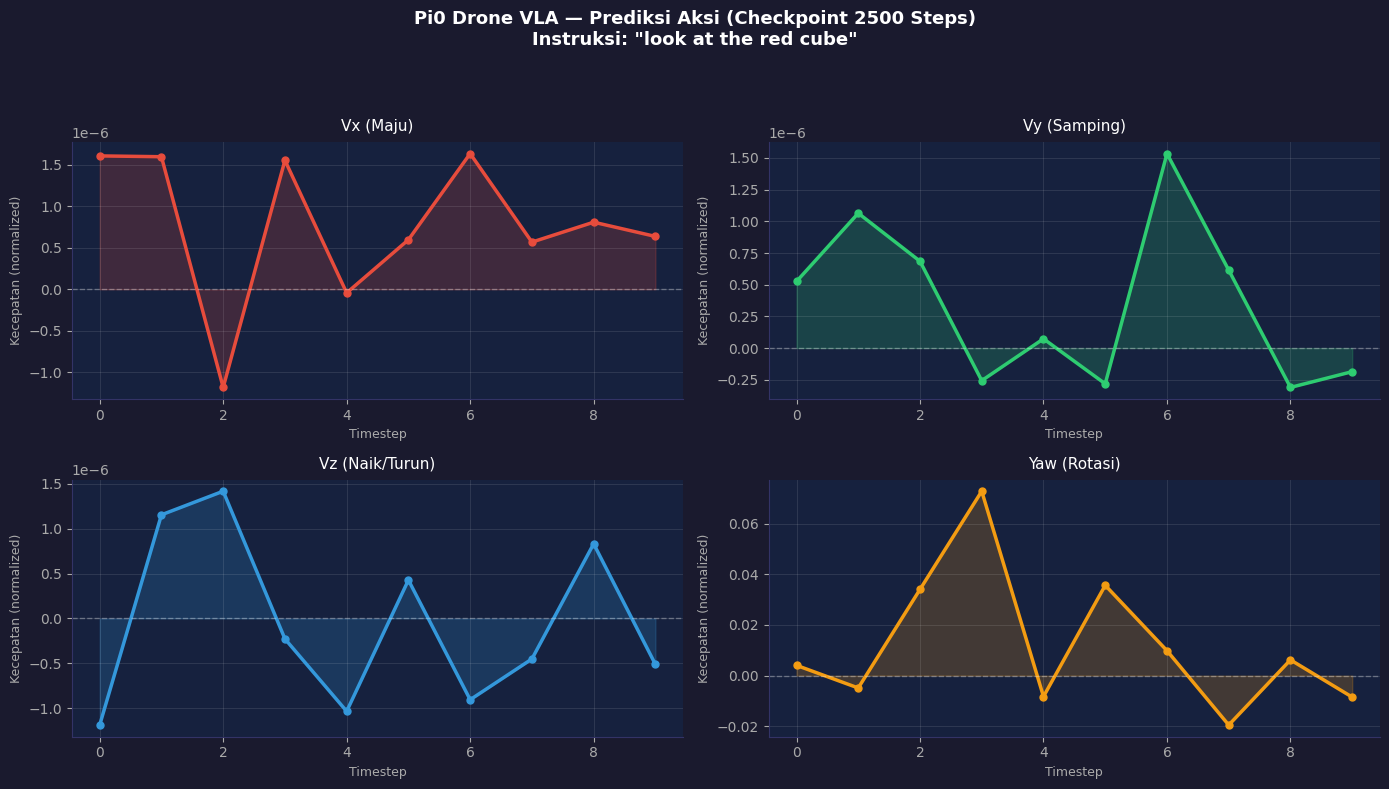


✅ Grafik disimpan ke: /kaggle/working/action_prediction.png


In [22]:
# ============================================================
# VISUALISASI PREDIKSI AKSI (Bonus)
# ============================================================
import matplotlib.pyplot as plt

timesteps = list(range(actions.shape[0]))
labels = ['Vx (Maju)', 'Vy (Samping)', 'Vz (Naik/Turun)', 'Yaw (Rotasi)']
colors = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12']

fig, axes = plt.subplots(2, 2, figsize=(14, 8), facecolor='#1a1a2e')
axes = axes.flatten()
fig.suptitle(
    f'Pi0 Drone VLA — Prediksi Aksi (Checkpoint 2500 Steps)\n'
    f'Instruksi: "{instruction}"',
    color='white', fontsize=13, fontweight='bold'
)

for i, (ax, label, color) in enumerate(zip(axes, labels, colors)):
    ax.set_facecolor('#16213e')
    ax.plot(timesteps, actions[:, i], color=color, linewidth=2.5, marker='o', markersize=5)
    ax.axhline(y=0, color='white', linestyle='--', alpha=0.3, linewidth=1)
    ax.fill_between(timesteps, actions[:, i], 0, alpha=0.2, color=color)
    ax.set_title(label, color='white', fontsize=11, pad=8)
    ax.set_xlabel('Timestep', color='#aaaaaa', fontsize=9)
    ax.set_ylabel('Kecepatan (normalized)', color='#aaaaaa', fontsize=9)
    ax.tick_params(colors='#aaaaaa')
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_color('#333366')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.1, color='white')

plt.tight_layout(rect=[0, 0, 1, 0.93])
output_path = '/kaggle/working/action_prediction.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print(f'\n✅ Grafik disimpan ke: {output_path}')

In [23]:
# ============================================================
# UJI BATCH: Beberapa Frame Sekaligus
# ============================================================
import glob

# Kumpulkan semua file gambar dari dataset cache
all_images = []
chunk_dir = os.path.join(TARGET_DATA_DIR, 'data', 'chunk-000')
if os.path.exists(chunk_dir):
    for ext in ['*.png', '*.jpg', '*.jpeg']:
        all_images.extend(sorted(glob.glob(os.path.join(chunk_dir, '**', ext), recursive=True)))

N_TEST = min(5, len(all_images))
print(f'Total gambar ditemukan: {len(all_images)}')
print(f'Menguji pada {N_TEST} frame pertama...\n')

if N_TEST == 0:
    print('Tidak ada gambar. Membuat 3 gambar dummy untuk uji batch...')
    dummy_images = [np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8) for _ in range(3)]
    test_source = [(f'dummy_frame_{i}', img) for i, img in enumerate(dummy_images)]
else:
    test_source = [(img_path, np.array(Image.open(img_path).convert('RGB').resize((224, 224)))) for img_path in all_images[:N_TEST]]

print(f'{"Frame":<30} {"Vx":>10} {"Vy":>10} {"Vz":>10} {"Yaw":>10}')
print('-' * 72)

for img_name_or_path, img in test_source:
    fname = os.path.basename(str(img_name_or_path)) if isinstance(img_name_or_path, str) else img_name_or_path
    obs = {
        'image': img,
        'state': np.zeros(4, dtype=np.float32),
        'task':  instruction,
    }
    with torch.no_grad():
        res = policy.infer(obs)
    first_action = res['actions'][0]  # Timestep pertama saja
    vx, vy, vz, yaw = first_action
    print(f'{str(fname):<30} {vx:>10.5f} {vy:>10.5f} {vz:>10.5f} {yaw:>10.5f}')

print('-' * 72)
print(f'\n✅ Batch test selesai pada {N_TEST} frame!')
print(f'   Semua output berhasil mengeluarkan 4 dimensi aksi.')

Total gambar ditemukan: 0
Menguji pada 0 frame pertama...

Tidak ada gambar. Membuat 3 gambar dummy untuk uji batch...
Frame                                  Vx         Vy         Vz        Yaw
------------------------------------------------------------------------
dummy_frame_0                     0.00000   -0.00000   -0.00000    0.00908
dummy_frame_1                     0.00000    0.00000   -0.00000    0.03462
dummy_frame_2                    -0.00000   -0.00000    0.00000   -0.05259
------------------------------------------------------------------------

✅ Batch test selesai pada 0 frame!
   Semua output berhasil mengeluarkan 4 dimensi aksi.
